In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Data Loadings and Preprocessing

In [ ]:
aapl_df = yf.download("AAPL", start = "2021-09-01", end = "2023-09-30")['Close']
aapl_df = aapl_df['AAPL']
aapl_df.head()

[*********************100%***********************]  1 of 1 completed


,AAPL
Date,
2021-09-01,148.882126
2021-09-02,149.995010
2021-09-03,150.629562
2021-09-07,152.962708
2021-09-08,151.420303


In [ ]:
msft_df = yf.download("MSFT", start = "2021-09-01", end = "2023-09-30")['Close']
msft_df = msft_df['MSFT']
msft_df.head()

[*********************100%***********************]  1 of 1 completed


,MSFT
Date,
2021-09-01,290.219849
2021-09-02,289.565948
2021-09-03,289.556396
2021-09-07,288.633301
2021-09-08,288.662109


In [ ]:
amzn_df = yf.download("AMZN", start = "2021-09-01", end = "2023-09-30")['Close']
amzn_df = amzn_df['AMZN']
amzn_df.head()

[*********************100%***********************]  1 of 1 completed


,AMZN
Date,
2021-09-01,173.949997
2021-09-02,173.156006
2021-09-03,173.902496
2021-09-07,175.464493
2021-09-08,176.274994


In [ ]:
aapl_smoothed_df = aapl_df.rolling(window = 5).mean().dropna()
msft_smoothed_df = msft_df.rolling(window = 5).mean().dropna()
amzn_smoothed_df = amzn_df.rolling(window = 5).mean().dropna()

# Data Splitting

In [ ]:
aapl_train_idx = int(len(aapl_smoothed_df)*0.8)
aapl_train = aapl_smoothed_df[:aapl_train_idx]
aapl_test = aapl_smoothed_df[aapl_train_idx:]

In [ ]:
msft_train_idx = int(len(msft_smoothed_df)*0.8)
msft_train = msft_smoothed_df[:msft_train_idx]
msft_test = msft_smoothed_df[msft_train_idx:]

In [ ]:
amzn_train_idx = int(len(amzn_smoothed_df)*0.8)
amzn_train = amzn_smoothed_df[:amzn_train_idx]
amzn_test = amzn_smoothed_df[amzn_train_idx:]

# Stationarity Test

In [ ]:
def check_stationarity(data):
    result = adfuller(data)
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])

In [ ]:
def plotACF(data, title):
  plot_acf(data)
  plt.title(title)
  plt.xlabel("Lag")
  plt.ylabel("Correlation")
  plt.show()


In [ ]:
def plotPACF(data, title):
  plot_pacf(data)
  plt.title(title)
  plt.xlabel("Lag")
  plt.ylabel("Correlation")
  plt.show()


## Apple

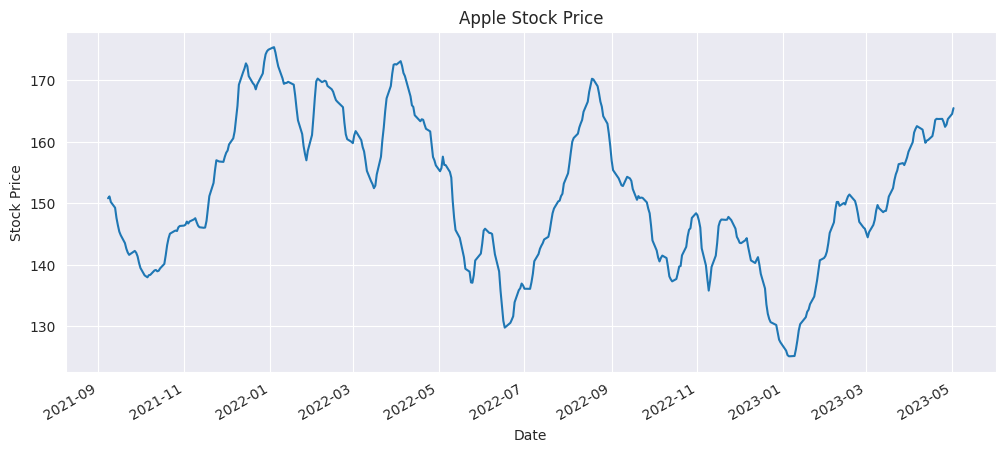

In [ ]:
plt.figure(figsize = (12, 5))
sns.set_style("darkgrid")
aapl_train.plot(kind = "line")
plt.title("Apple Stock Price")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.show()

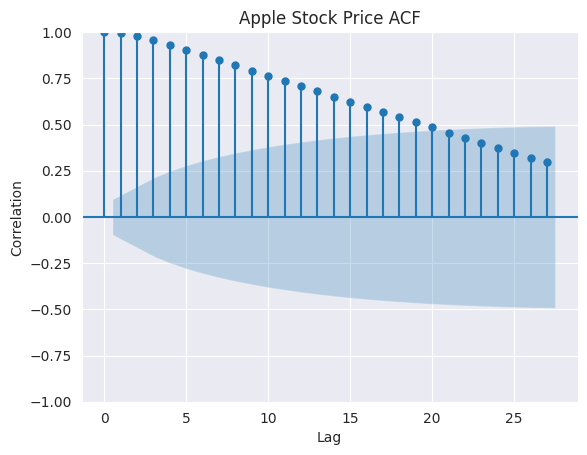

In [ ]:
plotACF(aapl_train, "Apple Stock Price ACF")

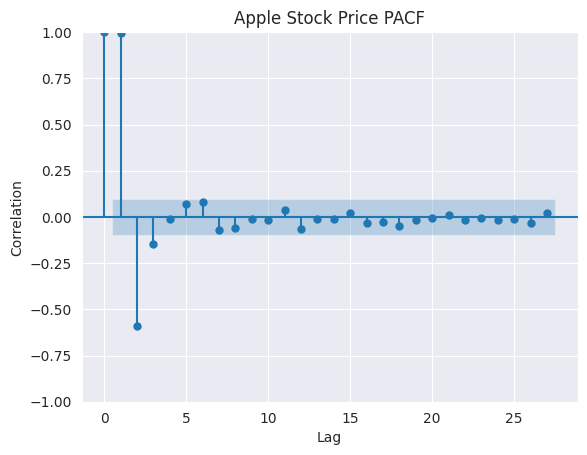

In [ ]:
plotPACF(aapl_train, "Apple Stock Price PACF")

In [ ]:
check_stationarity(aapl_train)

ADF Statistic: -2.838267
p-value: 0.053012


## Microsoft

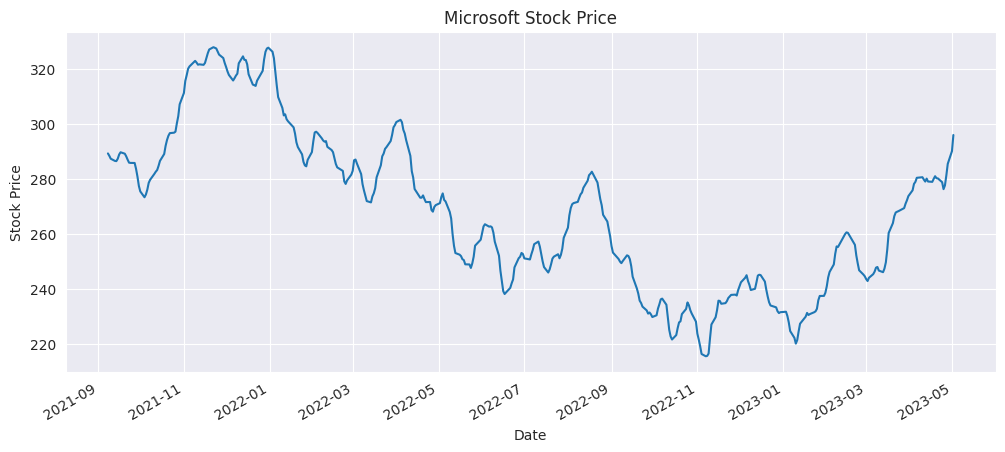

In [ ]:
plt.figure(figsize = (12, 5))
sns.set_style("darkgrid")
msft_train.plot(kind = "line")
plt.title("Microsoft Stock Price")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.show()

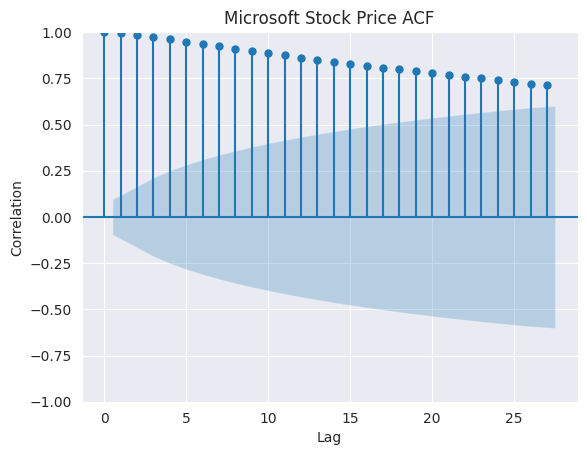

In [ ]:
plotACF(msft_train, "Microsoft Stock Price ACF")

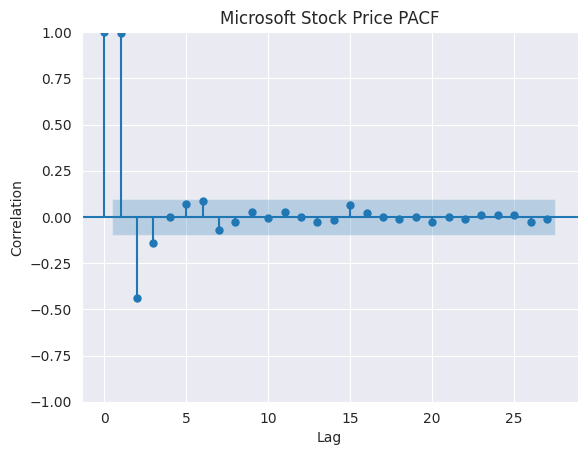

In [ ]:
plotPACF(msft_train, "Microsoft Stock Price PACF")

In [ ]:
check_stationarity(msft_train)

ADF Statistic: -1.340603
p-value: 0.610398


## Amazon

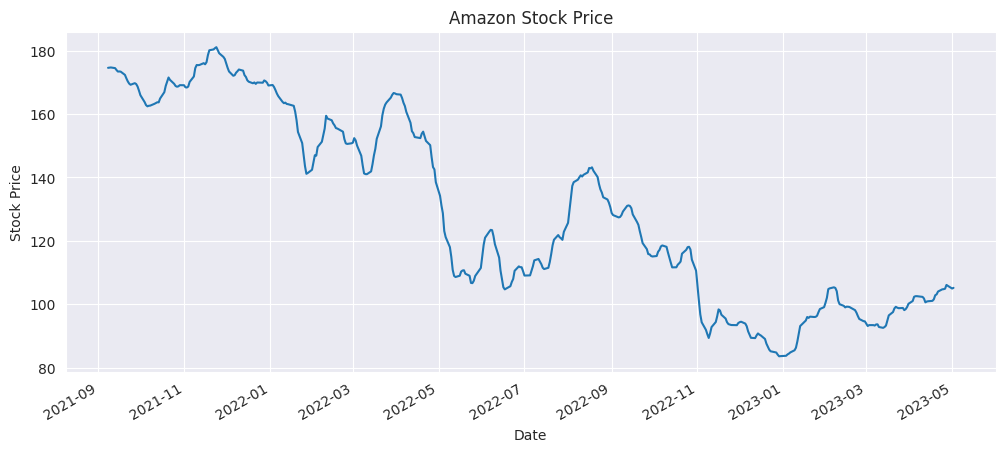

In [ ]:
plt.figure(figsize = (12, 5))
sns.set_style("darkgrid")
amzn_train.plot(kind = "line")
plt.title("Amazon Stock Price")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.show()

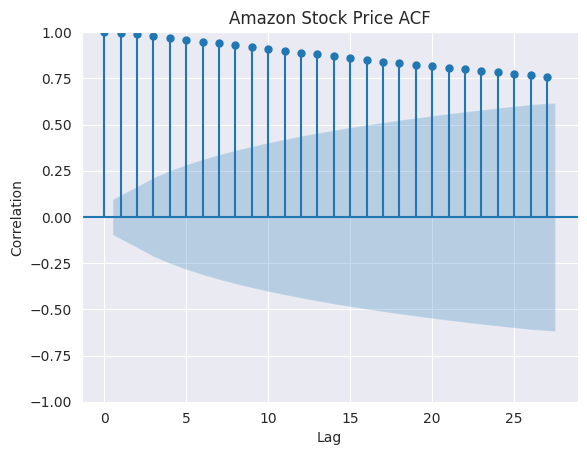

In [ ]:
plotACF(amzn_train, "Amazon Stock Price ACF")

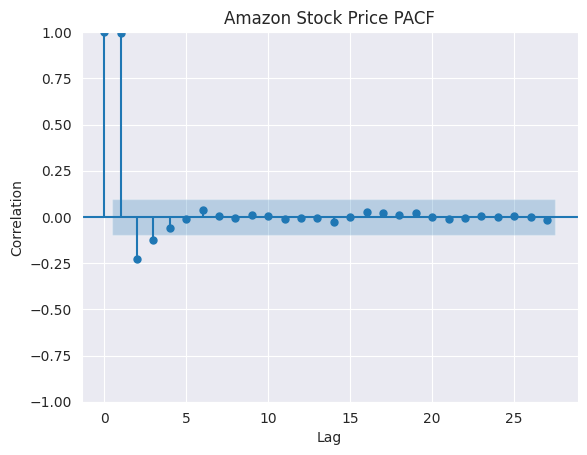

In [ ]:
plotPACF(amzn_train, "Amazon Stock Price PACF")

In [ ]:
check_stationarity(amzn_train)

ADF Statistic: -1.357639
p-value: 0.602408


# Differencing

## Apple

In [ ]:
aapl_diff_train_df = aapl_train.diff().dropna()

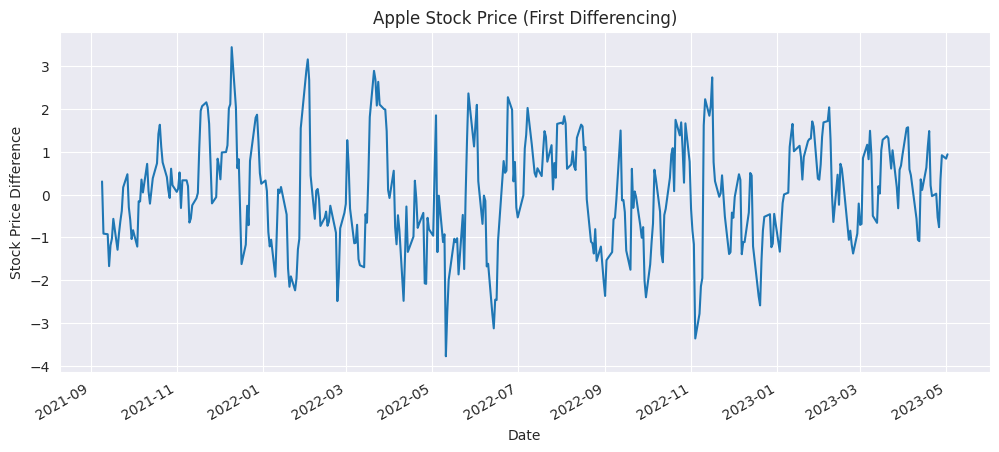

In [ ]:
plt.figure(figsize = (12, 5))
sns.set_style("darkgrid")
aapl_diff_train_df.plot(kind = "line")
plt.title("Apple Stock Price (First Differencing)")
plt.xlabel("Date")
plt.ylabel("Stock Price Difference")
plt.show()

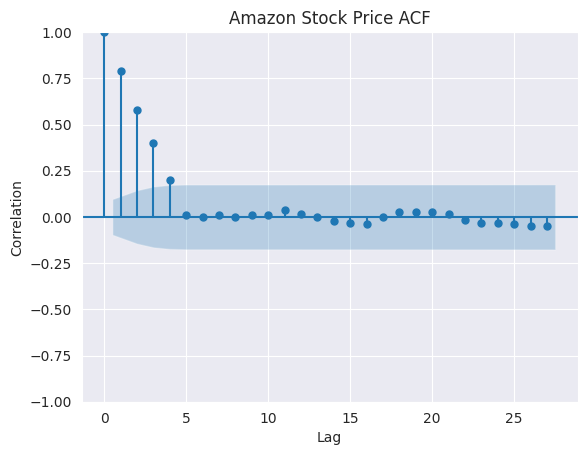

In [ ]:
plotACF(aapl_diff_train_df, "Amazon Stock Price ACF")

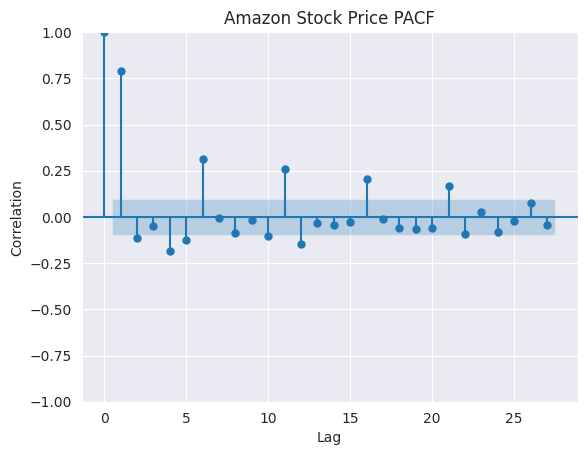

In [ ]:
plotPACF(aapl_diff_train_df, "Amazon Stock Price PACF")

In [ ]:
check_stationarity(aapl_diff_train_df)

ADF Statistic: -4.011751
p-value: 0.001350


## Microsoft

In [ ]:
msft_diff_train_df = msft_train.diff().dropna()

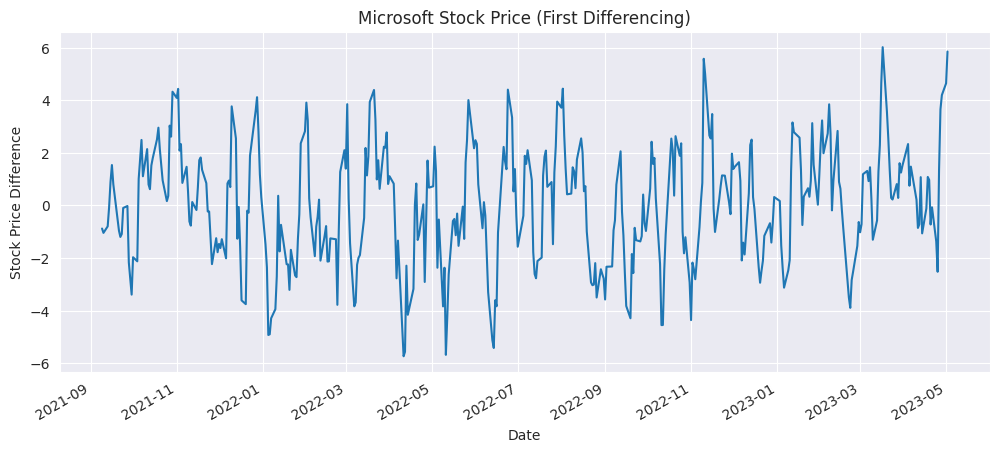

In [ ]:
plt.figure(figsize = (12, 5))
sns.set_style("darkgrid")
msft_diff_train_df.plot(kind = "line")
plt.title("Microsoft Stock Price (First Differencing)")
plt.xlabel("Date")
plt.ylabel("Stock Price Difference")
plt.show()

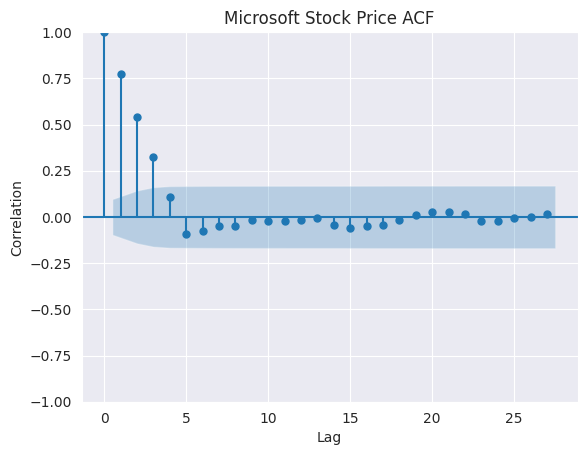

In [ ]:
plotACF(msft_diff_train_df, "Microsoft Stock Price ACF")

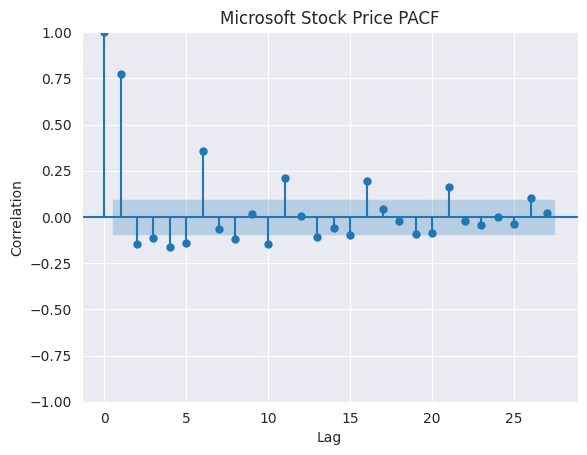

In [ ]:
plotPACF(msft_diff_train_df, "Microsoft Stock Price PACF")

In [ ]:
check_stationarity(msft_diff_train_df)

ADF Statistic: -4.477590
p-value: 0.000216


## Amazon

In [ ]:
amzn_diff_train_df = amzn_train.diff().dropna()

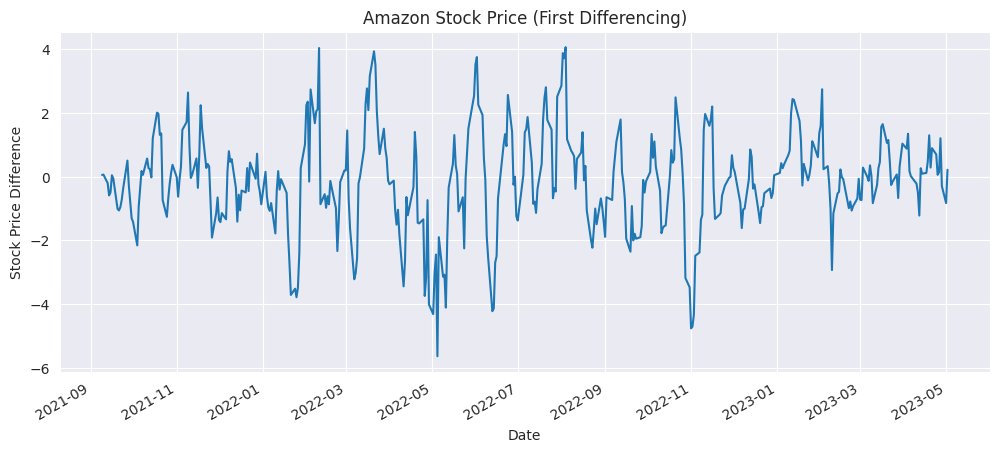

In [ ]:
plt.figure(figsize = (12, 5))
sns.set_style("darkgrid")
amzn_diff_train_df.plot(kind = "line")
plt.title("Amazon Stock Price (First Differencing)")
plt.xlabel("Date")
plt.ylabel("Stock Price Difference")
plt.show()

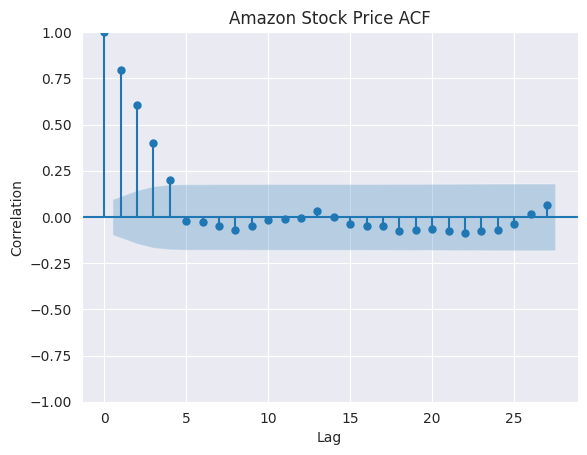

In [ ]:
plotACF(amzn_diff_train_df, "Amazon Stock Price ACF")

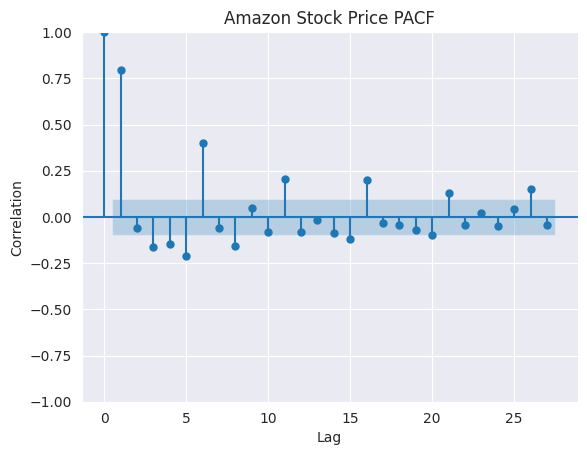

In [ ]:
plotPACF(amzn_diff_train_df, "Amazon Stock Price PACF")

In [ ]:
check_stationarity(amzn_diff_train_df)

ADF Statistic: -4.348132
p-value: 0.000366


# Model Training - ARIMA

## Apple

In [ ]:
aapl_model = ARIMA(aapl_train, order = (1, 1, 1))
aapl_model_fit = aapl_model.fit()
print(aapl_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   AAPL   No. Observations:                  415
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -473.699
Date:                Sun, 21 Jun 2026   AIC                            953.397
Time:                        15:06:14   BIC                            965.475
Sample:                             0   HQIC                           958.173
                                - 415                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7368      0.041     18.115      0.000       0.657       0.816
ma.L1          0.1387      0.060      2.305      0.021       0.021       0.257
sigma2         0.5759      0.031     18.320      0.0

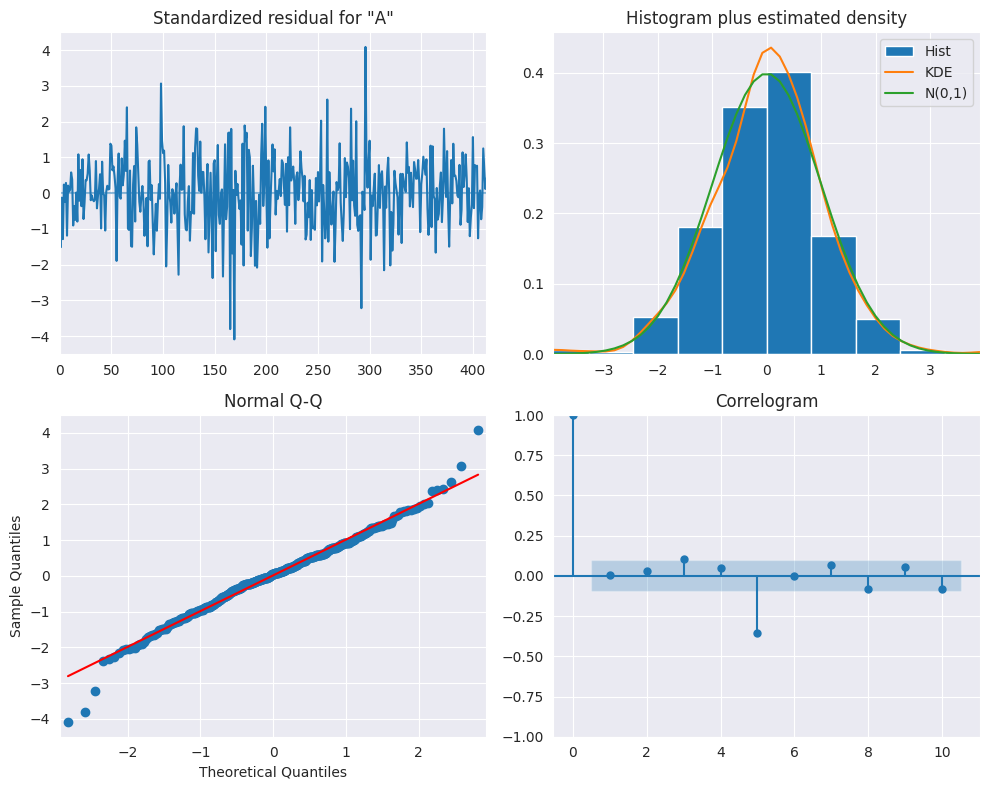

In [ ]:
aapl_model_fit.plot_diagnostics(figsize = (10, 8))
plt.tight_layout()
plt.show()


## Microsoft

In [ ]:
msft_model = ARIMA(msft_train, order = (1, 1, 1))
msft_model_fit = msft_model.fit()
print(msft_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   MSFT   No. Observations:                  415
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -720.896
Date:                Sun, 21 Jun 2026   AIC                           1447.791
Time:                        15:06:15   BIC                           1459.869
Sample:                             0   HQIC                          1452.567
                                - 415                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7272      0.043     16.903      0.000       0.643       0.811
ma.L1          0.1546      0.059      2.605      0.009       0.038       0.271
sigma2         1.9009      0.130     14.629      0.0

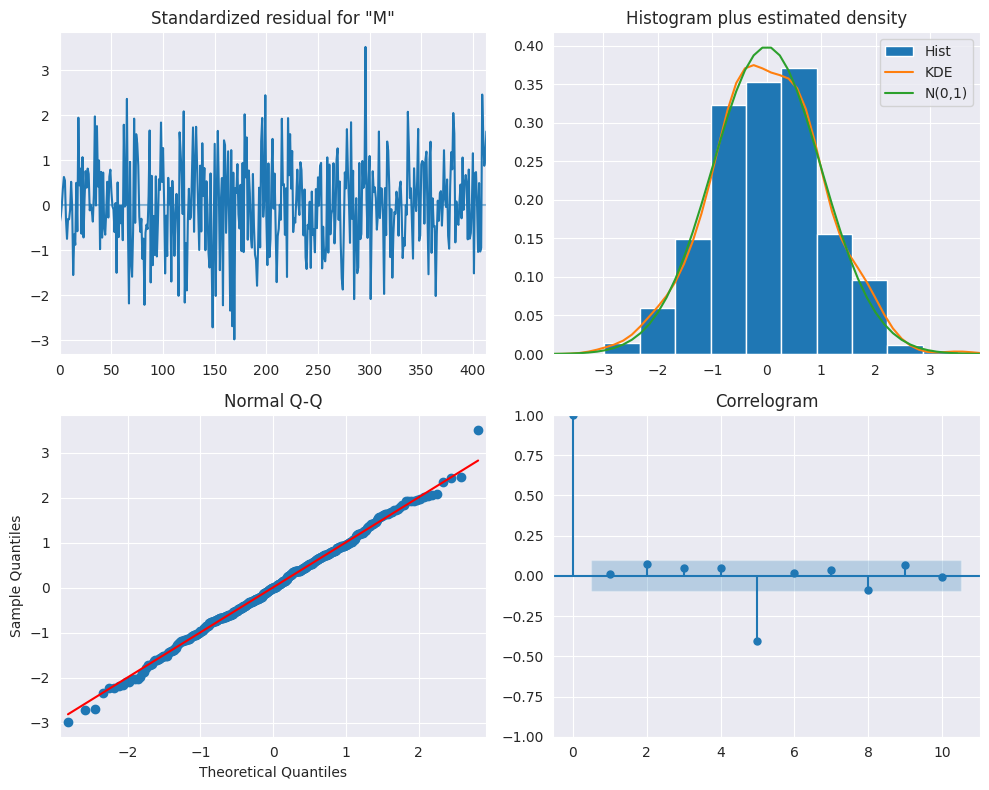

In [ ]:
msft_model_fit.plot_diagnostics(figsize = (10, 8))
plt.tight_layout()
plt.show()


## Amazon

In [ ]:
amzn_model = ARIMA(amzn_train, order = (2, 1, 2))
amzn_model_fit = amzn_model.fit()
print(amzn_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   AMZN   No. Observations:                  415
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -541.660
Date:                Sun, 21 Jun 2026   AIC                           1093.320
Time:                        15:06:16   BIC                           1113.449
Sample:                             0   HQIC                          1101.281
                                - 415                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4165      0.039    -10.747      0.000      -0.492      -0.341
ar.L2          0.2651      0.043      6.193      0.000       0.181       0.349
ma.L1          1.6330      0.057     28.533      0.0

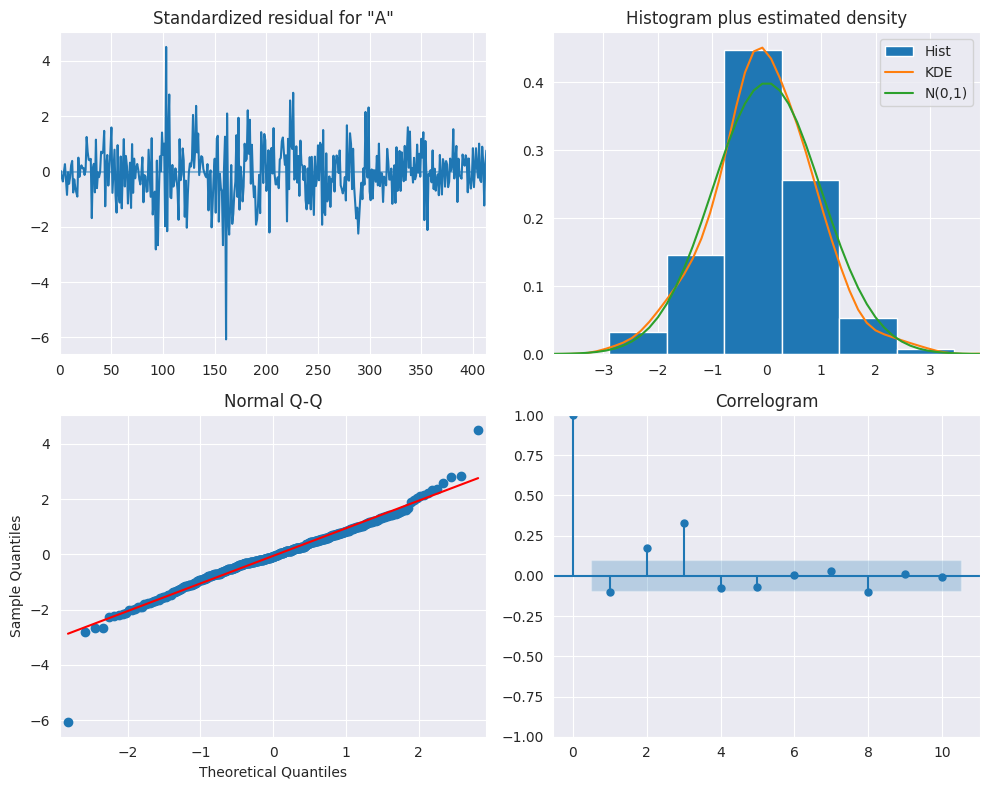

In [ ]:
amzn_model_fit.plot_diagnostics(figsize = (10, 8))
plt.tight_layout()
plt.show()


# Model Evaluation

In [ ]:
def rolling_forecasting(train_data, test_data, order):
  history = [x for x in train_data]
  predictions = list()

  for i in range(len(test_data)):
    model = ARIMA(history, order = order)
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = test_data[i]
    history.append(obs)

  return predictions


In [ ]:
def plotForecasting(actual_data, predict_data, title):
  plt.figure(figsize = (12, 5))
  actual_data.plot(kind = "line", label = "True")
  predict_data.plot(kind = "line", label = "Predictions")
  plt.title(title)
  plt.xlabel("Date")
  plt.ylabel("Stock Price")
  plt.legend()
  plt.show()

## Apple

In [ ]:
aapl_predictions = rolling_forecasting(aapl_train, aapl_test, (1, 1, 1))

In [ ]:
aapl_predictions = pd.Series(aapl_predictions, index = aapl_test.index)

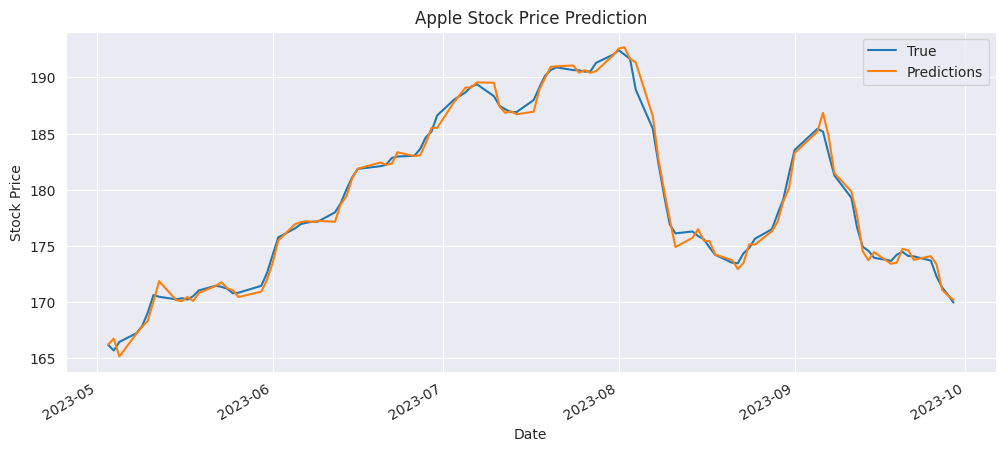

In [ ]:
plotForecasting(aapl_test, aapl_predictions, "Apple Stock Price Prediction")

In [ ]:
print(r2_score(aapl_test, aapl_predictions))
print(np.sqrt(mean_squared_error(aapl_test, aapl_predictions)))

0.9930192361747682
0.6194955527165823


## Microsoft

In [ ]:
msft_predictions = rolling_forecasting(msft_train, msft_test, (1, 1, 1))

In [ ]:
msft_predictions = pd.Series(msft_predictions, index = aapl_test.index)

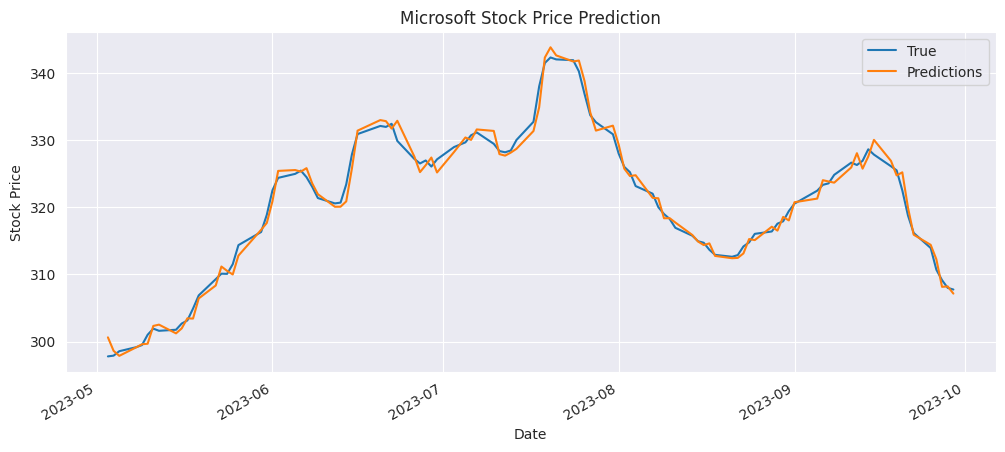

In [ ]:
plotForecasting(msft_test, msft_predictions, "Microsoft Stock Price Prediction")

In [ ]:
print(r2_score(msft_test, msft_predictions))
print(np.sqrt(mean_squared_error(msft_test, msft_predictions)))

0.9885468288873527
1.1488197507657243


## Amazon

In [ ]:
amzn_predictions = rolling_forecasting(amzn_train, amzn_test, (2, 1, 2))

In [ ]:
amzn_predictions = pd.Series(amzn_predictions, index = aapl_test.index)

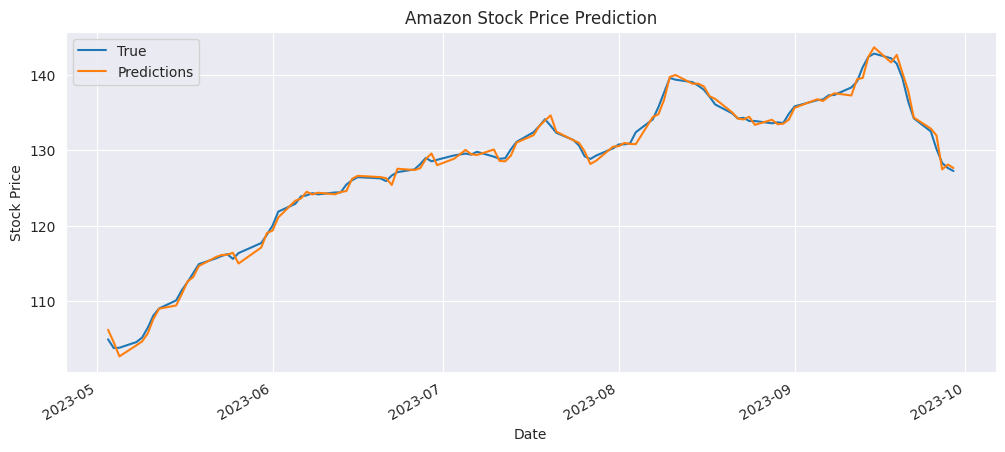

In [ ]:
plotForecasting(amzn_test, amzn_predictions, "Amazon Stock Price Prediction")

In [ ]:
print(r2_score(amzn_test, amzn_predictions))
print(np.sqrt(mean_squared_error(amzn_test, amzn_predictions)))

0.9957554988028209
0.6308640168860122
